# Project 1: Data Analysis Project

## Table of contents <a id='toc0_'></a>
- [Question 1: Inequality in Denmark](#toc1_)
  - [Question 1.1: The Gini Coefficient and the Top 10 Percent Share](#toc1_1_)
  - [Question 1.2: Prediction](#toc1_2_)
  - [Question 1.3: Municipalities](#toc1_3_)
  - [Question 1.4: Extension](#toc1_4_)
- [Question 2: Simulating the Income Distribution](#toc2_)
  - [Question 2.1: The Model](#toc2_1_)
  - [Question 2.2: Simulate the Income Distribution](#toc2_2_)
  - [Question 2.3: Compute the Gini Coefficient](#toc2_3_)
  - [Question 2.4: What Drives Inequality?](#toc2_4_)
  - [Question 2.5: Extension: More Risk](#toc2_5_)

We import the nessesary packages:

In [1]:
# Import all necessary packages
import numpy as np
import pandas as pd

# APIs
from dstapi import DstApi

# plotting
import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# functions
import dataproject

## Question 1: Inequality in Denmark <a id='toc1_'></a>

### Question 1.1: The Gini Coefficient and the Top 10 Percent Share <a id='toc1_1_'></a>

We start by getting a overview of the two datasets from Statistic Denmark (DST).

In [2]:
# Below are some lines of code to explore the datasets. 
# Theses are commented out in the final version of the notebook, 
# but they are used to get a better understanding of the data.

IFOR41 = DstApi('IFOR41') 
IFOR32 = DstApi('IFOR32')

#IFOR41.tablesummary(language='en')
#IFOR32.tablesummary(language='en')

#IFOR41.variable_levels('ULLIG',language='en')
#IFOR32.variable_levels('DECILGEN',language='en')

#IFOR41.variable_levels('KOMMUNEDK',language='en')

As the Hint in the project describing tells us is this Gini coefficient indicated by `ULLIG = 70`.

The data also consist of a municipality dimension with the 98 municipalities and a `All Denmark = 000`. We load all data about the Gini coefficient from all munipalities from 1987 in the begining since later exercises are exploring the municipality differences

In [3]:
# Download both datasets and store them in one inequality dataset.
df_IFOR41 = dataproject.load_IFOR41(ULLIG = '70', KOMMUNEDK = '*', varname='gini')
df_IFOR32 = dataproject.load_IFOR32(DECILGEN = '*', KOMMUNEDK = '*', varname='avg_income')

# Merge the two datasets into one dataset by year and municipality where year is the index.
df_ineq = pd.merge(df_IFOR32, df_IFOR41, 
                   on = ['year', 'municipality'], 
                   how='inner',
                   validate='1:1') # Passed: No merge error.

df_ineq = df_ineq.set_index(['year']).sort_index().sort_values(by=['municipality'])

df_ineq.head()

,municipality,avg_income_1,avg_income_10,avg_income_2,avg_income_3,avg_income_4,avg_income_5,avg_income_6,avg_income_7,avg_income_8,avg_income_9,avg_income_total,avg_income_top10_share,gini
year,,,,,,,,,,,,,,
1987,Aabenraa,32392.0,160791.0,57606.0,66307.0,74363.0,81428.0,88112.0,95331.0,103934.0,116181.0,876445.0,0.183458,21.33
1988,Aabenraa,31358.0,169217.0,61598.0,70739.0,79074.0,86487.0,93664.0,101235.0,110066.0,123171.0,926609.0,0.182620,21.51
1989,Aabenraa,37616.0,178127.0,66146.0,75469.0,83690.0,91194.0,98557.0,106459.0,116132.0,129661.0,983051.0,0.181198,20.74
1990,Aabenraa,39725.0,186215.0,68009.0,77905.0,86581.0,94380.0,101877.0,110088.0,119875.0,134453.0,1019108.0,0.182724,20.83
1991,Aabenraa,45258.0,200033.0,71517.0,81565.0,90363.0,98704.0,106954.0,115550.0,126194.0,142039.0,1078177.0,0.185529,20.86


We find that...

### Question 1.2: Prediction <a id='toc1_2_'></a>

To predict inequality in Denmark in 2030 and 2040, we compute the linear and quadratic trend to the Gini coefficient. We do this by first defining the polynomial trend of degree p, then solve the minimization problem to find the value of beta that best fits our data and compare it to np.plyfit

In [18]:
#define the polynomial function
def S(beta, t, y, p):
    # beta=[beta_0, beta_1,..., beta_p]
    pred=sum(beta[k]*t**k for k in range(p+1)) #calculating the inner sum
    return np.sum((y-pred)**2)

#import packages we need
from scipy import optimize

#compute time, so that it is years since 1987 and define the gini variable as a vector:
time= (df_ineq.index.values - df_ineq.index.min())
gini = df_ineq['gini'].values

# 1. Now, we find the values of beta, beta_hat1 and beta_hat2 that best fit the data-points

degrees= [1,2]
results={}

print("when using optimize.minimize, the results are:")
for p in degrees:
    initial_guess = np.zeros(p+1) #make the vector
    initial_guess[0] = gini.mean() #and guess it is the mean 
    res = optimize.minimize(S, initial_guess, args=(time, gini, p), method='Nelder-Mead')
    results[p] = res

    
    print(f"for p = {p}")
    print(f"  success: {res.success}")
    print(f"  coefficients (betahat_0 ... betahat_{p}): {res.x}")
    print(f"  S(betahat) at optimum: {res.fun}")
    print()

# 2. We now check the results against np.polyfit
# for linear, p=1
poly_1=np.polyfit(time, gini, 1)
poly_2=np.polyfit(time, gini, 2)

print("when using np.polyfit, the results are:")
print(f'for p=1, betahat={poly_1}')
print(f'for p=2, betahat={poly_2}')


when using optimize.minimize, the results are:
for p = 1
  success: True
  coefficients (betahat_0 ... betahat_1): [20.14133619  0.20970358]
  S(betahat) at optimum: 40310.14168013688

for p = 2
  success: True
  coefficients (betahat_0 ... betahat_2): [2.02794336e+01 1.86686707e-01 6.22033869e-04]
  S(betahat) at optimum: 40293.32771517319

when using np.polyfit, the results are:
for p=1, betahat=[ 0.20970221 20.14134912]
for p=2, betahat=[6.22225096e-04 1.86679880e-01 2.02794831e+01]


So we find that both methods find the same values of $\hat{\beta}$. We find that the linear trend finds that in the first year, 1987, gini coefficient is around 20 and rises slightly every year, which is also what we found in the figure in 1.1.
Furthermore, we find that the fit of the linear and quadratic trend are almost the same, meaning there is little to be gained by using the quadratic polynomial trend. 

We now use the estimates to predict what the gini coefficient is in 2030 and 2040, by using the function predict

p=1
  predicted Gini coefficient in 2030: 29.16
  predicted Gini coefficient in 2040: 31.26

p=2
  predicted Gini coefficient in 2030: 29.46
  predicted Gini coefficient in 2040: 31.92



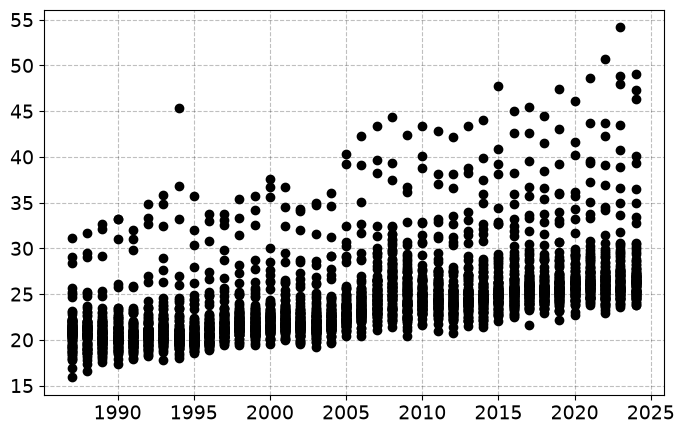

In [20]:
# 3. We predict the Gini coefficient in 2030 and 2040, and plot the result

def predict(beta, t, p):
    return sum(beta[k]*t**k for k in range(p+1))

#define the two predictions we want
t_2030= 2030-1987
t_2040=2040-1987

for p in degrees:
    beta=results[p].x
    pred_2030=predict(beta, t_2030, p)
    pred_2040=predict(beta, t_2040, p)

    print(f"p={p}")
    print(f"  predicted Gini coefficient in 2030: {pred_2030:.2f}")
    print(f"  predicted Gini coefficient in 2040: {pred_2040:.2f}")
    print()

# We now plot the values  with the historic data:
plt.figure(figsize=(8,5))
plt.scatter(time+1987, gini, color='black', label='Observed data') #time+1987 so the data again is shown for year


We find that ...

### Question 1.3: Municipalities <a id='toc1_3_'></a>

We look at different municipalities...

In [6]:
# Write the code here.

We find that ...

### Question 1.4: Extension <a id='toc1_4_'></a>

We extent the analysis on municipalities by...

In [7]:
# Write the code here.

We find that ...

## Question 2: Simulating the Income Distribution <a id='toc2_'></a>

### Question 2.1: The Model <a id='toc2_1_'></a>

We construct the model by...

In [8]:
# Write the code here.

We find that ...

### Question 2.2: Simulate the Income Distribution <a id='toc2_2_'></a>

We simulate the model by...

In [9]:
# Write the code here.

We find that ...

### Question 2.3: Compute the Gini Coefficient <a id='toc2_3_'></a>

We comepute the gini by...

In [10]:
# Write the code here.

We find that ...

### Question 2.4: What Drives Inequality? <a id='toc2_4_'></a>

We at inequality by...

In [11]:
# Write the code here.

We find that ...

### Question 2.5: Extension: More Risk <a id='toc2_5_'></a>

We extent the model by...

In [12]:
# Write the code here.

We find that ...